<a href="https://colab.research.google.com/github/hc2twv/textQ-melody/blob/main/textQ_melody.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install qiskit qiskit-aer qiskit-algorithms qiskit-optimization qiskit_machine_learning pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.0/660.0 kB 20.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 75.1 MB/s 

In [3]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ============================================================
# MODULE 1: SEMANTIC-MUSICAL TEXT ANALYSIS
# ============================================================

# Affect lexicon: (valence, arousal) in [0,1]
# For a real paper: use NRC VAD Lexicon or SentiWordNet
AFFECT_LEXICON = {
    # Positive-Calm
    'quiet': (0.8, 0.2), 'peace': (0.9, 0.1), 'sweet': (0.8, 0.3),
    'soft': (0.7, 0.2), 'serene': (0.8, 0.2), 'love': (0.9, 0.4),
    'light': (0.7, 0.5), 'breeze': (0.6, 0.3), 'rests': (0.7, 0.1),
    'gentle': (0.8, 0.2), 'calm': (0.8, 0.1), 'warm': (0.7, 0.3),
    'dream': (0.7, 0.2), 'embrace': (0.8, 0.3), 'meadow': (0.7, 0.2),
    # Positive-Energetic
    'joy': (0.9, 0.8), 'party': (0.8, 0.9), 'dance': (0.7, 0.9),
    'run': (0.5, 0.9), 'fire': (0.4, 0.9), 'shines': (0.8, 0.7),
    'bright': (0.8, 0.7), 'sing': (0.8, 0.7), 'laugh': (0.9, 0.8),
    'blaze': (0.5, 0.9), 'celebrate': (0.9, 0.8), 'leap': (0.7, 0.8),
    # Negative-Calm
    'sad': (0.2, 0.2), 'melancholy': (0.2, 0.3), 'forgotten': (0.3, 0.2),
    'shadow': (0.3, 0.3), 'silence': (0.4, 0.1), 'night': (0.4, 0.3),
    'lonely': (0.2, 0.2), 'fade': (0.3, 0.2), 'cold': (0.3, 0.3),
    'weep': (0.2, 0.3), 'sorrow': (0.2, 0.3), 'dark': (0.3, 0.3),
    # Negative-Energetic
    'storm': (0.2, 0.9), 'scream': (0.3, 0.9), 'destroy': (0.1, 0.9),
    'thunder': (0.2, 0.8), 'chaos': (0.1, 0.9), 'war': (0.1, 0.8),
    'rage': (0.2, 0.9), 'crash': (0.2, 0.8), 'fury': (0.2, 0.9),
    'roar': (0.3, 0.8), 'shatter': (0.1, 0.9), 'burn': (0.3, 0.8),
}


def analyze_text(text):
    """
    Extract a semantic-musical vector from a text paragraph.

    Returns:
        dict with valence, arousal, density, stress_pattern,
        sentence_lengths, tempo, mode, n_words
    """
    import re
    words = re.findall(r'\w+', text.lower())
    sentences = [s.strip() for s in re.split(r'[.!?;]', text) if s.strip()]

    # Lexicon-based affect analysis
    valences, arousals = [], []
    for w in words:
        if w in AFFECT_LEXICON:
            v, a = AFFECT_LEXICON[w]
            valences.append(v)
            arousals.append(a)

    avg_valence = np.mean(valences) if valences else 0.5
    avg_arousal = np.mean(arousals) if arousals else 0.5

    # Lexical density (proxy: long words / total)
    content_words = [w for w in words if len(w) > 3]
    density = len(content_words) / max(len(words), 1)

    # Sentence lengths -> musical phrase structure
    sent_lengths = [len(re.findall(r'\w+', s)) for s in sentences]

    # Simplified stress pattern
    # Long words or vowel-initial -> stressed (strong beat)
    # Short function words -> unstressed (weak beat)
    stress_pattern = []
    for w in words:
        if len(w) > 4 or w[0] in 'aeiou':
            stress_pattern.append(1)  # Strong
        else:
            stress_pattern.append(0)  # Weak

    tempo = int(60 + avg_arousal * 120)  # 60-180 BPM
    mode = 'major' if avg_valence > 0.5 else 'minor'

    return {
        'valence': avg_valence,
        'arousal': avg_arousal,
        'density': density,
        'sentence_lengths': sent_lengths,
        'stress_pattern': stress_pattern[:16],
        'tempo': tempo,
        'mode': mode,
        'n_words': len(words),
    }


In [4]:
# ============================================================
# MODULE 2: SCALES AND MUSIC THEORY
# ============================================================

SCALES = {
    'major':          [0, 2, 4, 5, 7, 9, 11, 12],
    'minor':          [0, 2, 3, 5, 7, 8, 10, 12],
    'minor_harmonic': [0, 2, 3, 5, 7, 8, 11, 12],
}

NOTE_NAMES = {
    60:'C4', 62:'D4', 63:'Eb4', 64:'E4', 65:'F4',
    67:'G4', 68:'Ab4', 69:'A4', 70:'Bb4', 71:'B4', 72:'C5'
}

CONSONANCE = {
    0: 1.0, 2: 0.5, 3: 0.8, 4: 0.8, 5: 0.7,
    7: 0.9, 8: 0.6, 9: 0.6, 10: 0.4, 11: 0.3, 12: 1.0
}


def get_scale_midi(mode, root=60):
    """Return MIDI values for the selected scale."""
    return [root + i for i in SCALES.get(mode, SCALES['major'])]


In [5]:
# ============================================================
# MODULE 3: SEMANTICALLY-CONDITIONED VARIATIONAL CIRCUIT
# ============================================================

def create_conditioned_circuit(note_params, semantic_bias):
    """
    3-qubit variational circuit CONDITIONED by text semantics.

    Key innovation: the initial rotation angles are derived from
    the text's semantic vector. The optimizer tunes ADDITIONAL
    parameters on top of this semantic base.

    Args:
        note_params: 6 trainable parameters per note
        semantic_bias: 3 values derived from text semantics
    """
    qc = QuantumCircuit(3)

    # === LAYER 0: Semantic preparation (FIXED, not optimizable) ===
    # The text "programs" the circuit's initial state
    for i in range(3):
        qc.ry(semantic_bias[i], i)
    qc.cx(0, 1)
    qc.cx(1, 2)

    # === LAYERS 1-2: Variational (trainable) ===
    idx = 0
    for layer in range(2):
        for qubit in range(3):
            qc.ry(note_params[idx], qubit)
            idx += 1
        qc.cx(0, 1)
        qc.cx(1, 2)
        qc.cx(2, 0)  # Circular entanglement

    return qc


def semantic_to_bias(sem, note_position, total_notes):
    """
    Map semantic vector to circuit bias for each note position.

    Position within the phrase matters:
    - Phrase start  -> tonic stability (grounded state)
    - Phrase middle -> exploration (broader superposition)
    - Phrase end    -> resolution (tendency toward tonic/dominant)
    """
    progress = note_position / max(total_notes - 1, 1)

    # Valence -> register (high valence = higher pitch tendency)
    register_bias = sem['valence'] * np.pi

    # Arousal -> state spread (high arousal = more notes accessible)
    spread_bias = sem['arousal'] * np.pi * 0.5

    # Position -> melodic arch (rise toward middle, descend at end)
    arch = np.sin(progress * np.pi) * np.pi * 0.3

    # Stress pattern -> amplify or attenuate
    stress = sem['stress_pattern']
    stress_mod = stress[note_position] * 0.3 if note_position < len(stress) else 0.0

    return [
        register_bias + stress_mod,
        spread_bias + arch,
        progress * np.pi * 0.5  # Resolution tendency
    ]


In [6]:
# ============================================================
# MODULE 4: MELODY GENERATION AND COST FUNCTION
# ============================================================

def generate_melody(theta, sem, scale_midi, n_notes):
    """Generate melody from parameters + semantics."""
    params_per_note = 6
    melody = []
    for i in range(n_notes):
        note_params = theta[i * params_per_note : (i+1) * params_per_note]
        bias = semantic_to_bias(sem, i, n_notes)
        qc = create_conditioned_circuit(note_params, bias)
        sv = Statevector.from_instruction(qc)
        probs = sv.probabilities()
        melody.append(scale_midi[int(np.argmax(probs))])
    return melody


def musical_cost(theta, sem, scale_midi, n_notes):
    """
    Hybrid semantic-musical cost function (to MINIMIZE).

    Combines six objectives:
      1. Harmonic consonance
      2. Melodic smoothness
      3. Pitch variety
      4. Semantic coherence (arousal <-> movement)
      5. Melodic arch (climax placement)
      6. Tonal resolution (ending on tonic/dominant)
    """
    melody = generate_melody(theta, sem, scale_midi, n_notes)
    n = len(melody)

    # 1. Harmonic consonance between consecutive notes
    harm = sum(CONSONANCE.get(abs(melody[i] - melody[i+1]), 0.2)
               for i in range(n - 1)) / max(n - 1, 1)

    # 2. Melodic smoothness (steps preferred over leaps)
    smooth = 0.0
    for i in range(n - 1):
        step = abs(melody[i] - melody[i+1])
        smooth += 1.0 if step <= 4 else (0.4 if step <= 7 else 0.1)
    smooth /= max(n - 1, 1)

    # 3. Pitch variety
    variety = len(set(melody)) / n

    # 4. Semantic coherence: arousal should match movement magnitude
    expected_movement = sem['arousal'] * 7
    actual_movement = np.mean([abs(melody[i] - melody[i+1]) for i in range(n-1)])
    sem_coherence = max(0, 1.0 - abs(expected_movement - actual_movement) / 12)

    # 5. Melodic arch: climax ideally near 60% of the melody
    climax_pos = np.argmax(melody) / max(n - 1, 1)
    arch_score = 1.0 - abs(climax_pos - 0.6)

    # 6. Resolution: last note should be tonic or dominant
    resolution = (1.0 if melody[-1] == scale_midi[0] else
                  0.7 if melody[-1] == scale_midi[4] else 0.3)

    total = (0.20 * harm + 0.20 * smooth + 0.10 * variety +
             0.20 * sem_coherence + 0.15 * arch_score + 0.15 * resolution)

    return -total

In [7]:
# ============================================================
# MODULE 5: MAIN PIPELINE
# ============================================================

def compose_from_text(text, seed=42):
    """Full pipeline: text -> semantic analysis -> quantum circuit -> melody."""
    print("=" * 60)
    print("  TextQ-Melody: Quantum Music Composition from Text")
    print("=" * 60)

    # Step 1: Semantic analysis
    sem = analyze_text(text)
    scale_midi = get_scale_midi(sem['mode'])
    n_notes = min(max(sem['n_words'], 8), 16)

    print(f'\nInput text: "{text}"')
    print(f"\nSemantic Analysis:")
    print(f"  Valence:  {sem['valence']:.2f} ({'positive' if sem['valence'] > 0.5 else 'negative'})")
    print(f"  Arousal:  {sem['arousal']:.2f} ({'energetic' if sem['arousal'] > 0.5 else 'calm'})")
    print(f"  Mode:     {sem['mode']}")
    print(f"  Tempo:    {sem['tempo']} BPM")
    print(f"  Notes:    {n_notes}")
    print(f"  Scale:    {[NOTE_NAMES.get(m, str(m)) for m in scale_midi]}")

    # Step 2: Variational optimization
    n_params = n_notes * 6
    np.random.seed(seed)
    theta0 = np.random.uniform(0, 2 * np.pi, n_params)

    melody_init = generate_melody(theta0, sem, scale_midi, n_notes)
    print(f"\nInitial melody (random):")
    print(f"  {[NOTE_NAMES.get(m, str(m)) for m in melody_init]}")
    print(f"  Cost: {musical_cost(theta0, sem, scale_midi, n_notes):.4f}")

    print(f"\nOptimizing variational circuit ({n_params} parameters)...")
    result = minimize(
        musical_cost, theta0,
        args=(sem, scale_midi, n_notes),
        method='COBYLA',
        options={'maxiter': 800, 'rhobeg': 0.5}
    )

    melody_opt = generate_melody(result.x, sem, scale_midi, n_notes)
    print(f"\nOptimized melody:")
    print(f"  {[NOTE_NAMES.get(m, str(m)) for m in melody_opt]}")
    print(f"  Cost:        {result.fun:.4f}")
    print(f"  Evaluations: {result.nfev}")

    intervals = [abs(melody_opt[i] - melody_opt[i+1]) for i in range(len(melody_opt)-1)]
    print(f"\nMelody Analysis:")
    print(f"  Range:       {NOTE_NAMES.get(min(melody_opt))} -> {NOTE_NAMES.get(max(melody_opt))}")
    print(f"  Avg interval: {np.mean(intervals):.1f} semitones")
    print(f"  Unique notes: {len(set(melody_opt))}/{n_notes}")
    print(f"  Final note:   {NOTE_NAMES.get(melody_opt[-1])}")

    return {
        'text': text,
        'semantic': sem,
        'melody_midi': melody_opt,
        'melody_names': [NOTE_NAMES.get(m, str(m)) for m in melody_opt],
        'initial_melody': [NOTE_NAMES.get(m, str(m)) for m in melody_init],
        'params': result.x,
        'cost': result.fun,
        'n_evals': result.nfev,
    }



In [8]:
# ============================================================
# MODULE 6: VISUALIZATION
# ============================================================

def plot_results(results):
    """Generate comparative visualization of all compositions."""
    n = len(results)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, r in enumerate(results):
        melody = r['melody_midi']
        sem = r['semantic']
        scale = get_scale_midi(sem['mode'])

        # Panel 1: Piano roll
        ax = axes[i, 0]
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(melody)))
        for j, note in enumerate(melody):
            ax.barh(note, 0.8, left=j, color=colors[j],
                    edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.set_yticks(scale)
        ax.set_yticklabels([NOTE_NAMES.get(m, str(m)) for m in scale])
        ax.set_xlabel('Time step')
        ax.set_ylabel('Note')
        # Truncate title if text is long
        title_text = r['text'][:50] + ('...' if len(r['text']) > 50 else '')
        ax.set_title(f'Piano Roll\n"{title_text}"', fontsize=9)
        ax.grid(True, alpha=0.3)

        # Panel 2: Intervals
        ax = axes[i, 1]
        intervals = [melody[j+1] - melody[j] for j in range(len(melody)-1)]
        bar_colors = ['#2ecc71' if abs(iv) <= 4 else
                      '#f39c12' if abs(iv) <= 7 else
                      '#e74c3c' for iv in intervals]
        ax.bar(range(len(intervals)), intervals, color=bar_colors,
               edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.set_xlabel('Transition')
        ax.set_ylabel('Interval (semitones)')
        ax.set_title(f'Melodic Intervals\nMode: {sem["mode"]} | Tempo: {sem["tempo"]} BPM',
                     fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

        # Panel 3: Quantum probability distribution (first note)
        ax = axes[i, 2]
        note_params = r['params'][:6]
        bias = semantic_to_bias(sem, 0, len(melody))
        qc = create_conditioned_circuit(note_params, bias)
        sv = Statevector.from_instruction(qc)
        probs = sv.probabilities()
        note_labels = [NOTE_NAMES.get(m, str(m)) for m in scale]
        ax.bar(note_labels, probs, color='coral',
               edgecolor='darkred', alpha=0.85)
        ax.set_xlabel('Note')
        ax.set_ylabel('Probability')
        ax.set_title(f'Quantum Distribution (1st note)\n'
                     f'Val={sem["valence"]:.2f} Aro={sem["arousal"]:.2f}',
                     fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('textq_melody_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nVisualization saved to textq_melody_results.png")


In [9]:
!pip install MIDIUtil pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for MIDIUtil: filename=MIDIUtil-1.2.1-py3-none-any.whl size=54569 sha256=6e4b64ead32395175a67f1e3fc336ffeebaeba6bad47140b0f8b088f8b63143b
  Stored in directory: /root/.cache/pip/wheels/88/7f/1a/19f62946c3c836b60cf789576f327f73ad8778a7e954e998c3
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=825fae151874cfd8d4dc9f3d19817d202e01e888c7cd5034c19690833ca16567
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built MIDIUtil pylatexenc


In [10]:
# ============================================================
# MODULE 7: MIDI FILE EXPORT
# ============================================================
from midiutil import MIDIFile


def export_midi(result, filename=None, velocity_from_stress=True):
    """
    Export a TextQ-Melody composition to a playable MIDI file.

    Features:
      - Tempo derived from text arousal
      - Note velocities shaped by stress pattern (loud on content words)
      - Duration variation: stressed notes are longer
      - Adds a simple tonic pedal on channel 2 for harmonic context

    Args:
        result: dict returned by compose_from_text()
        filename: output path (auto-generated if None)
        velocity_from_stress: if True, stress pattern modulates velocity
    """
    sem = result['semantic']
    melody = result['melody_midi']
    tempo = sem['tempo']
    mode = sem['mode']
    n_notes = len(melody)

    midi = MIDIFile(
        numTracks=2,
        removeDuplicates=True,
        deinterleave=True
    )

    # Track 0: Melody
    track_melody = 0
    channel_melody = 0
    midi.addTrackName(track_melody, 0, "TextQ-Melody")
    midi.addTempo(track_melody, 0, tempo)

    # Track 1: Pedal / drone (harmonic context)
    track_pedal = 1
    channel_pedal = 1
    midi.addTrackName(track_pedal, 0, "Pedal")
    midi.addTempo(track_pedal, 0, tempo)

    # --- Melody instrument based on mood ---
    # Calm -> Piano (0), Energetic -> Strings (48),
    # Negative+Calm -> Oboe (68), Negative+Energetic -> Brass (61)
    if sem['valence'] > 0.5 and sem['arousal'] <= 0.5:
        melody_program = 0    # Acoustic Grand Piano
    elif sem['valence'] > 0.5 and sem['arousal'] > 0.5:
        melody_program = 48   # String Ensemble
    elif sem['valence'] <= 0.5 and sem['arousal'] <= 0.5:
        melody_program = 68   # Oboe
    else:
        melody_program = 61   # Brass Section

    midi.addProgramChange(track_melody, channel_melody, 0, melody_program)
    midi.addProgramChange(track_pedal, channel_pedal, 0, 0)  # Piano pedal

    # --- Build melody with expressive timing ---
    stress = sem['stress_pattern']
    time_cursor = 0.0

    for i, note in enumerate(melody):
        # Velocity: stressed syllables are louder
        if velocity_from_stress and i < len(stress):
            velocity = 90 + stress[i] * 25  # 90 (weak) or 115 (strong)
        else:
            velocity = 100

        # Duration: stressed notes slightly longer (swing feel)
        if i < len(stress) and stress[i] == 1:
            duration = 1.2  # Dotted quarter feel
        else:
            duration = 0.8  # Shorter, passing

        # Last note is longer (fermata)
        if i == n_notes - 1:
            duration = 2.0

        midi.addNote(
            track=track_melody,
            channel=channel_melody,
            pitch=note,
            time=time_cursor,
            duration=duration,
            volume=int(velocity)
        )
        time_cursor += 1.0  # Advance one beat

    # --- Pedal tone: root note sustained every 2 beats ---
    scale_midi = get_scale_midi(mode)
    root = scale_midi[0]       # Tonic
    fifth = scale_midi[4]      # Dominant
    total_beats = n_notes

    for beat in range(0, total_beats, 2):
        # Alternate tonic and dominant for basic harmonic motion
        pedal_note = root if (beat // 2) % 2 == 0 else fifth
        midi.addNote(
            track=track_pedal,
            channel=channel_pedal,
            pitch=pedal_note - 12,  # One octave below
            time=beat,
            duration=2.0,
            volume=50  # Soft background
        )

    # --- Write file ---
    if filename is None:
        # Auto-name from first few words
        import re
        slug = re.sub(r'[^\w]+', '_', result['text'][:30]).strip('_').lower()
        filename = f"textq_{slug}.mid"

    with open(filename, 'wb') as f:
        midi.writeFile(f)

    print(f"  MIDI exported: {filename}")
    print(f"    Instrument: {melody_program} | Tempo: {tempo} BPM")
    print(f"    Duration:   ~{total_beats * 60 / tempo:.1f} seconds")

    return filename


def export_all(results):
    """
    Export all compositions + a combined file with all three.
    """
    filenames = []

    print("\n" + "=" * 60)
    print("  MIDI EXPORT")
    print("=" * 60)

    # Individual files
    for i, r in enumerate(results):
        print(f"\n[Composition {i+1}]")
        fn = export_midi(r, filename=f"textq_composition_{i+1}.mid")
        filenames.append(fn)

    # Combined file: all melodies sequenced with 2-beat gaps
    print(f"\n[Combined]")
    combined = MIDIFile(numTracks=1, removeDuplicates=True, deinterleave=True)
    combined.addTrackName(0, 0, "TextQ-Melody Combined")
    combined.addTempo(0, 0, 100)  # Neutral tempo for combined
    combined.addProgramChange(0, 0, 0, 0)  # Piano

    time_cursor = 0.0
    for i, r in enumerate(results):
        melody = r['melody_midi']
        sem = r['semantic']

        # Set tempo for this section
        combined.addTempo(0, time_cursor, sem['tempo'])

        # Instrument change per section
        if sem['valence'] > 0.5 and sem['arousal'] <= 0.5:
            prog = 0
        elif sem['valence'] > 0.5 and sem['arousal'] > 0.5:
            prog = 48
        elif sem['valence'] <= 0.5 and sem['arousal'] <= 0.5:
            prog = 68
        else:
            prog = 61
        combined.addProgramChange(0, 0, time_cursor, prog)

        for j, note in enumerate(melody):
            stress = r['semantic']['stress_pattern']
            vel = 90 + (stress[j] * 25 if j < len(stress) else 0)
            dur = 1.2 if (j < len(stress) and stress[j] == 1) else 0.8
            if j == len(melody) - 1:
                dur = 2.0
            combined.addNote(0, 0, note, time_cursor, dur, int(vel))
            time_cursor += 1.0

        time_cursor += 2.0  # Gap between pieces

    with open('textq_combined.mid', 'wb') as f:
        combined.writeFile(f)
    print(f"  MIDI exported: textq_combined.mid")
    print(f"    Total duration: ~{time_cursor * 60 / 100:.1f} seconds")

    return filenames + ['textq_combined.mid']




In [11]:
# ============================================================
# MODULE 8: CIRCUIT VISUALIZATION
# ============================================================
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def draw_single_note_circuit(result, note_index=0, decompose=False):
    """
    Draw the full quantum circuit used to generate a specific note.
    Shows semantic conditioning (Layer 0) + variational layers (1-2).
    """
    sem = result['semantic']
    scale_midi = get_scale_midi(sem['mode'])
    n_notes = len(result['melody_midi'])

    note_params = result['params'][note_index * 6 : (note_index + 1) * 6]
    bias = semantic_to_bias(sem, note_index, n_notes)

    # Build circuit with barriers to separate layers visually
    qc = QuantumCircuit(3, 3)  # Add classical bits for measurement

    # === LAYER 0: Semantic conditioning (FIXED) ===
    qc.ry(bias[0], 0)
    qc.ry(bias[1], 1)
    qc.ry(bias[2], 2)
    qc.cx(0, 1)
    qc.cx(1, 2)

    qc.barrier(label="Semantic")

    # === LAYER 1: Variational ===
    qc.ry(note_params[0], 0)
    qc.ry(note_params[1], 1)
    qc.ry(note_params[2], 2)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 0)

    qc.barrier(label="Var L1")

    # === LAYER 2: Variational ===
    qc.ry(note_params[3], 0)
    qc.ry(note_params[4], 1)
    qc.ry(note_params[5], 2)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 0)

    qc.barrier(label="Var L2")

    # Measurement
    qc.measure([0, 1, 2], [0, 1, 2])

    note_name = NOTE_NAMES.get(result['melody_midi'][note_index], '?')

    fig = qc.draw(
        output='mpl',
        style={'backgroundcolor': '#FFFFFF'},
        plot_barriers=True,
        fold=-1  # Don't fold the circuit
    )
    fig.suptitle(
        f'Circuit for Note {note_index + 1}: {note_name}\n'
        f'Semantic bias: [{bias[0]:.2f}, {bias[1]:.2f}, {bias[2]:.2f}] rad\n'
        f'Variational params: [{', '.join(f"{p:.2f}" for p in note_params)}] rad',
        fontsize=10, y=1.05
    )
    plt.tight_layout()
    return fig, qc


def draw_melody_circuits(result, max_notes=None):
    """
    Draw circuits for ALL notes in the melody side by side,
    with their probability distributions below.
    """
    sem = result['semantic']
    scale_midi = get_scale_midi(sem['mode'])
    melody = result['melody_midi']
    n_notes = len(melody)

    if max_notes is None:
        max_notes = min(n_notes, 8)  # Show up to 8 for readability

    fig = plt.figure(figsize=(3.5 * max_notes, 10))
    gs = gridspec.GridSpec(3, max_notes, height_ratios=[2, 1.5, 0.3], hspace=0.4)

    note_labels = [NOTE_NAMES.get(m, str(m)) for m in scale_midi]

    for i in range(max_notes):
        note_params = result['params'][i * 6 : (i + 1) * 6]
        bias = semantic_to_bias(sem, i, n_notes)

        # --- Top row: Mini circuit diagram ---
        ax_circ = fig.add_subplot(gs[0, i])

        # Draw a schematic representation (text-based for compactness)
        note_name = NOTE_NAMES.get(melody[i], '?')
        circuit_text = (
            f"q0: RY({bias[0]:.1f})─●─RY({note_params[0]:.1f})─●─RY({note_params[3]:.1f})─●─\n"
            f"q1: RY({bias[1]:.1f})─X─RY({note_params[1]:.1f})─●─RY({note_params[4]:.1f})─●─\n"
            f"q2: RY({bias[2]:.1f})───RY({note_params[2]:.1f})─X─RY({note_params[5]:.1f})─X─"
        )
        ax_circ.text(0.5, 0.5, circuit_text,
                     fontfamily='monospace', fontsize=6,
                     ha='center', va='center',
                     transform=ax_circ.transAxes,
                     bbox=dict(boxstyle='round,pad=0.3',
                              facecolor='lightyellow', edgecolor='gray'))
        ax_circ.set_title(f'Note {i+1}: {note_name}', fontsize=9, fontweight='bold')
        ax_circ.axis('off')

        # --- Middle row: Probability distribution ---
        ax_prob = fig.add_subplot(gs[1, i])
        qc = create_conditioned_circuit(note_params, bias)
        sv = Statevector.from_instruction(qc)
        probs = sv.probabilities()

        colors = ['#e74c3c' if scale_midi[k] == melody[i] else '#3498db'
                  for k in range(8)]
        ax_prob.bar(range(8), probs, color=colors, edgecolor='black',
                    linewidth=0.5, alpha=0.85)
        ax_prob.set_xticks(range(8))
        ax_prob.set_xticklabels(note_labels, fontsize=6, rotation=45)
        ax_prob.set_ylabel('P' if i == 0 else '', fontsize=8)
        ax_prob.set_ylim(0, 1.05)
        ax_prob.tick_params(axis='y', labelsize=6)
        ax_prob.grid(True, alpha=0.3, axis='y')

        # Annotate selected note probability
        selected_idx = scale_midi.index(melody[i])
        ax_prob.annotate(f'{probs[selected_idx]:.2f}',
                        xy=(selected_idx, probs[selected_idx]),
                        ha='center', va='bottom', fontsize=7,
                        fontweight='bold', color='#e74c3c')

        # --- Bottom row: Semantic bias indicator ---
        ax_sem = fig.add_subplot(gs[2, i])
        progress = i / max(n_notes - 1, 1)
        ax_sem.barh(0, progress, color='#2ecc71', height=0.5, alpha=0.7)
        ax_sem.set_xlim(0, 1)
        ax_sem.set_yticks([])
        ax_sem.set_xticks([])
        if i == 0:
            ax_sem.set_ylabel('Pos', fontsize=7)
        ax_sem.set_xlabel(f'{progress:.0%}', fontsize=7)

    title_text = result['text'][:80] + ('...' if len(result['text']) > 80 else '')
    fig.suptitle(
        f'TextQ-Melody Circuit Analysis\n'
        f'"{title_text}"\n'
        f'Mode: {sem["mode"]} | Tempo: {sem["tempo"]} BPM | '
        f'Valence: {sem["valence"]:.2f} | Arousal: {sem["arousal"]:.2f}',
        fontsize=11, y=1.02
    )

    plt.savefig('textq_circuits.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Circuit analysis saved to textq_circuits.png")
    return fig


def draw_full_qiskit_circuit(result, note_index=0):
    """
    Draw circuit using pure matplotlib (no pylatexenc dependency).
    """
    sem = result['semantic']
    n_notes = len(result['melody_midi'])
    note_params = result['params'][note_index * 6 : (note_index + 1) * 6]
    bias = semantic_to_bias(sem, note_index, n_notes)
    note_name = NOTE_NAMES.get(result['melody_midi'][note_index], '?')

    # Build the circuit (for statevector, not for drawing)
    qc = create_conditioned_circuit(note_params, bias)

    # Get probability distribution
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities()
    scale_midi = get_scale_midi(sem['mode'])
    note_labels = [NOTE_NAMES.get(m, str(m)) for m in scale_midi]

    # --- Draw manually with matplotlib ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                             gridspec_kw={'width_ratios': [2.5, 1]})

    # LEFT: Circuit diagram as styled text
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, 3.5)
    ax.axis('off')

    # Wire lines
    for q in range(3):
        y = 2.5 - q
        ax.plot([0.5, 9.5], [y, y], 'k-', linewidth=0.8)
        ax.text(0.2, y, f'q{q}', fontsize=10, ha='center', va='center',
                fontweight='bold')

    # Gate drawing helper
    def draw_gate(x, y, label, color='#D4E6F1', w=0.7, h=0.5):
        rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                             facecolor=color, edgecolor='black', linewidth=1)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center', fontsize=6.5)

    def draw_cx(x, ctrl_y, targ_y):
        ax.plot(x, ctrl_y, 'ko', markersize=6)
        ax.plot([x, x], [ctrl_y, targ_y], 'k-', linewidth=1)
        ax.plot(x, targ_y, 'ko', markersize=10, fillstyle='none', markeredgewidth=1.5)
        ax.plot([x-0.08, x+0.08], [targ_y, targ_y], 'k-', linewidth=1.5)
        ax.plot([x, x], [targ_y-0.08, targ_y+0.08], 'k-', linewidth=1.5)

    # SEMANTIC LAYER (yellow)
    sem_color = '#FFF9C4'
    for q in range(3):
        draw_gate(1.3, 2.5 - q, f'RY\n{bias[q]:.2f}', color=sem_color)
    draw_cx(2.2, 2.5, 1.5)  # CX 0->1
    draw_cx(2.7, 1.5, 0.5)  # CX 1->2

    # Barrier
    for q in range(3):
        ax.plot([3.2, 3.2], [2.5 - q - 0.3, 2.5 - q + 0.3],
                'r--', linewidth=1, alpha=0.5)
    ax.text(3.2, 3.2, 'Semantic', fontsize=7, ha='center',
            color='red', alpha=0.7)

    # VARIATIONAL LAYER 1 (blue)
    var_color = '#D4E6F1'
    for q in range(3):
        draw_gate(4.0, 2.5 - q, f'RY\n{note_params[q]:.2f}', color=var_color)
    draw_cx(4.9, 2.5, 1.5)
    draw_cx(5.4, 1.5, 0.5)
    draw_cx(5.9, 0.5, 2.5)

    # Barrier
    for q in range(3):
        ax.plot([6.4, 6.4], [2.5 - q - 0.3, 2.5 - q + 0.3],
                'r--', linewidth=1, alpha=0.5)
    ax.text(6.4, 3.2, 'Var L1', fontsize=7, ha='center',
            color='red', alpha=0.7)

    # VARIATIONAL LAYER 2 (blue)
    for q in range(3):
        draw_gate(7.2, 2.5 - q, f'RY\n{note_params[3+q]:.2f}', color=var_color)
    draw_cx(8.1, 2.5, 1.5)
    draw_cx(8.6, 1.5, 0.5)
    draw_cx(9.1, 0.5, 2.5)

    ax.text(9.3, 3.2, 'Var L2', fontsize=7, ha='center',
            color='red', alpha=0.7)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=sem_color, edgecolor='black', label='Semantic (fixed)'),
        Patch(facecolor=var_color, edgecolor='black', label='Variational (trained)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

    ax.set_title(
        f'Quantum Circuit → Note {note_index+1}: {note_name}\n'
        f'Valence={sem["valence"]:.2f}  Arousal={sem["arousal"]:.2f}  '
        f'Mode={sem["mode"]}',
        fontsize=10
    )

    # RIGHT: Probability distribution
    ax2 = axes[1]
    selected_idx = scale_midi.index(result['melody_midi'][note_index])
    colors = ['#e74c3c' if k == selected_idx else '#3498db' for k in range(8)]
    ax2.bar(range(8), probs, color=colors, edgecolor='black',
            linewidth=0.5, alpha=0.85)
    ax2.set_xticks(range(8))
    ax2.set_xticklabels(note_labels, fontsize=8)
    ax2.set_ylabel('Probability')
    ax2.set_title(f'Output Distribution\nSelected: {note_name} (P={probs[selected_idx]:.3f})',
                  fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, 1.05)

    # Annotate
    ax2.annotate(f'{probs[selected_idx]:.3f}',
                xy=(selected_idx, probs[selected_idx]),
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', color='#e74c3c')

    plt.tight_layout()
    filename = f'circuit_note_{note_index+1}.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Circuit saved to {filename}")
    print(f"  Semantic bias:  {[f'{b:.3f}' for b in bias]}")
    print(f"  Var params L1:  {[f'{p:.3f}' for p in note_params[:3]]}")
    print(f"  Var params L2:  {[f'{p:.3f}' for p in note_params[3:]]}")
    print(f"  Output note:    {note_name} (MIDI {result['melody_midi'][note_index]})")

    return fig, qc

In [12]:
!pip install pylatexenc
import importlib
import qiskit.utils.lazy_tester
importlib.reload(qiskit.utils.lazy_tester)

<module 'qiskit.utils.lazy_tester' from '/usr/local/lib/python3.12/dist-packages/qiskit/utils/lazy_tester.py'>

  TextQ-Melody: Quantum Music Composition from Text

Input text: "The quiet night rests over the calm meadow. Silence embraces the gentle shadow with peace."

Semantic Analysis:
  Valence:  0.64 (positive)
  Arousal:  0.18 (calm)
  Mode:     major
  Tempo:    81 BPM
  Notes:    15
  Scale:    ['C4', 'D4', 'E4', 'F4', 'G4', 'A4', 'B4', 'C5']

Initial melody (random):
  ['D4', 'C4', 'E4', 'F4', 'E4', 'E4', 'A4', 'A4', 'G4', 'C5', 'C4', 'B4', 'C5', 'C5', 'A4']
  Cost: -0.6910

Optimizing variational circuit (90 parameters)...

Optimized melody:
  ['D4', 'C4', 'E4', 'F4', 'E4', 'G4', 'A4', 'A4', 'C5', 'C5', 'B4', 'B4', 'C5', 'C5', 'A4']
  Cost:        -0.7684
  Evaluations: 485

Melody Analysis:
  Range:       C4 -> C5
  Avg interval: 1.5 semitones
  Unique notes: 8/15
  Final note:   A4
  TextQ-Melody: Quantum Music Composition from Text

Input text: "The storm screams with fury. Thunder shatters the silence. Chaos and fire roar through the dark."

Semantic Analysis:
  Valence:  0.26 (neg

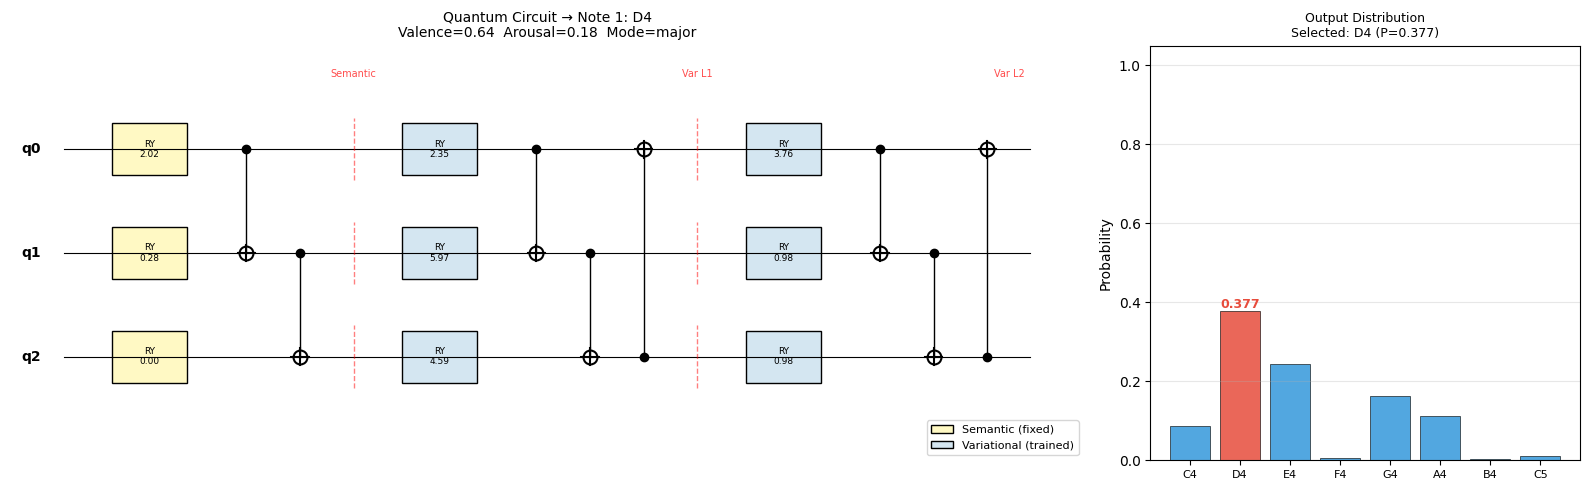

Circuit saved to circuit_note_1.png
  Semantic bias:  ['2.025', '0.279', '0.000']
  Var params L1:  ['2.353', '5.970', '4.590']
  Var params L2:  ['3.758', '0.976', '0.976']
  Output note:    D4 (MIDI 62)

[Storm text - Note 1]


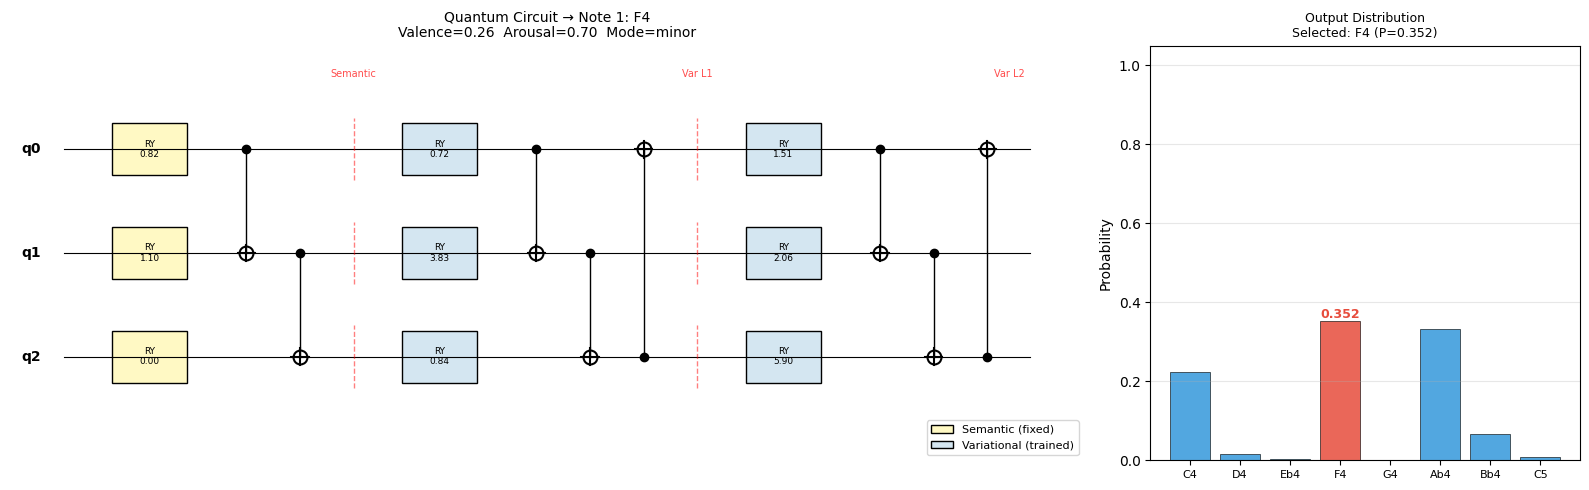

Circuit saved to circuit_note_1.png
  Semantic bias:  ['0.825', '1.100', '0.000']
  Var params L1:  ['0.723', '3.827', '0.838']
  Var params L2:  ['1.512', '2.055', '5.898']
  Output note:    F4 (MIDI 65)

[Full melody circuit analysis - Calm text]


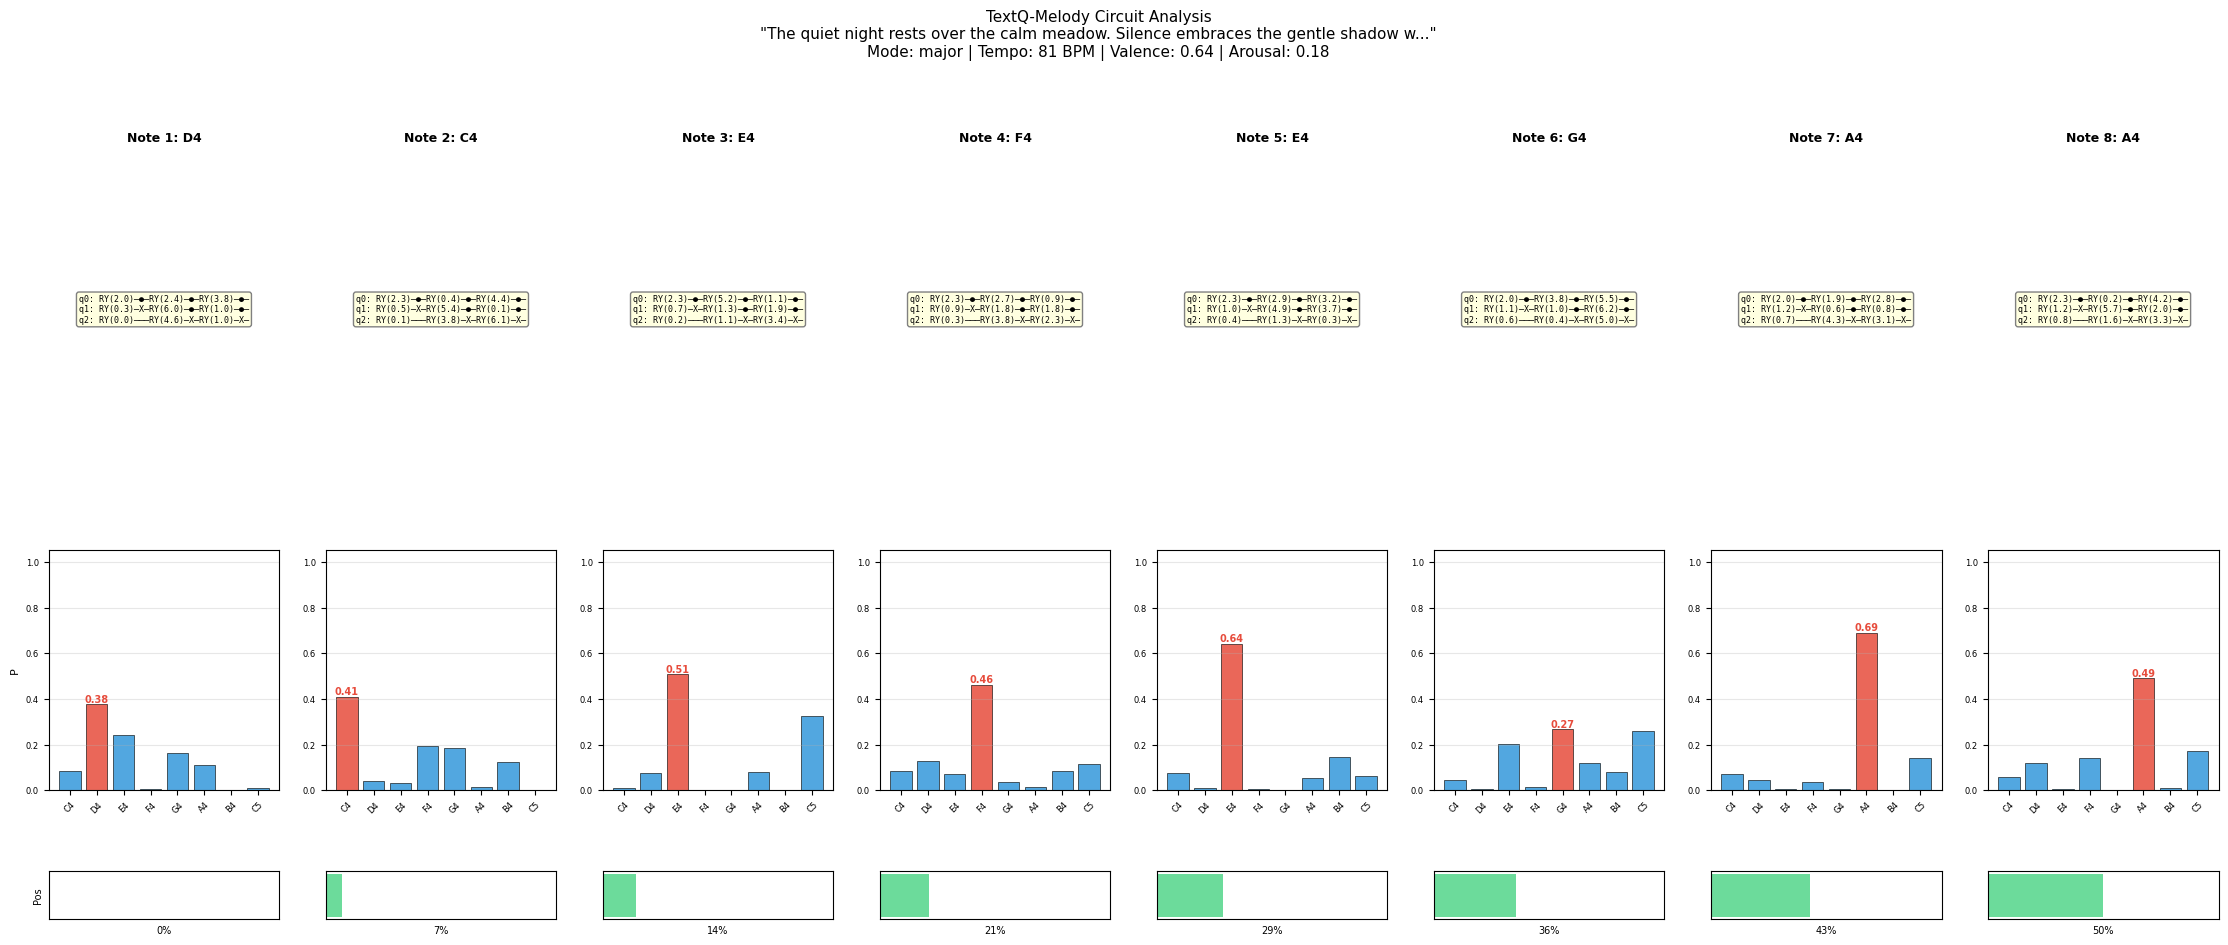

Circuit analysis saved to textq_circuits.png

[Full melody circuit analysis - Storm text]


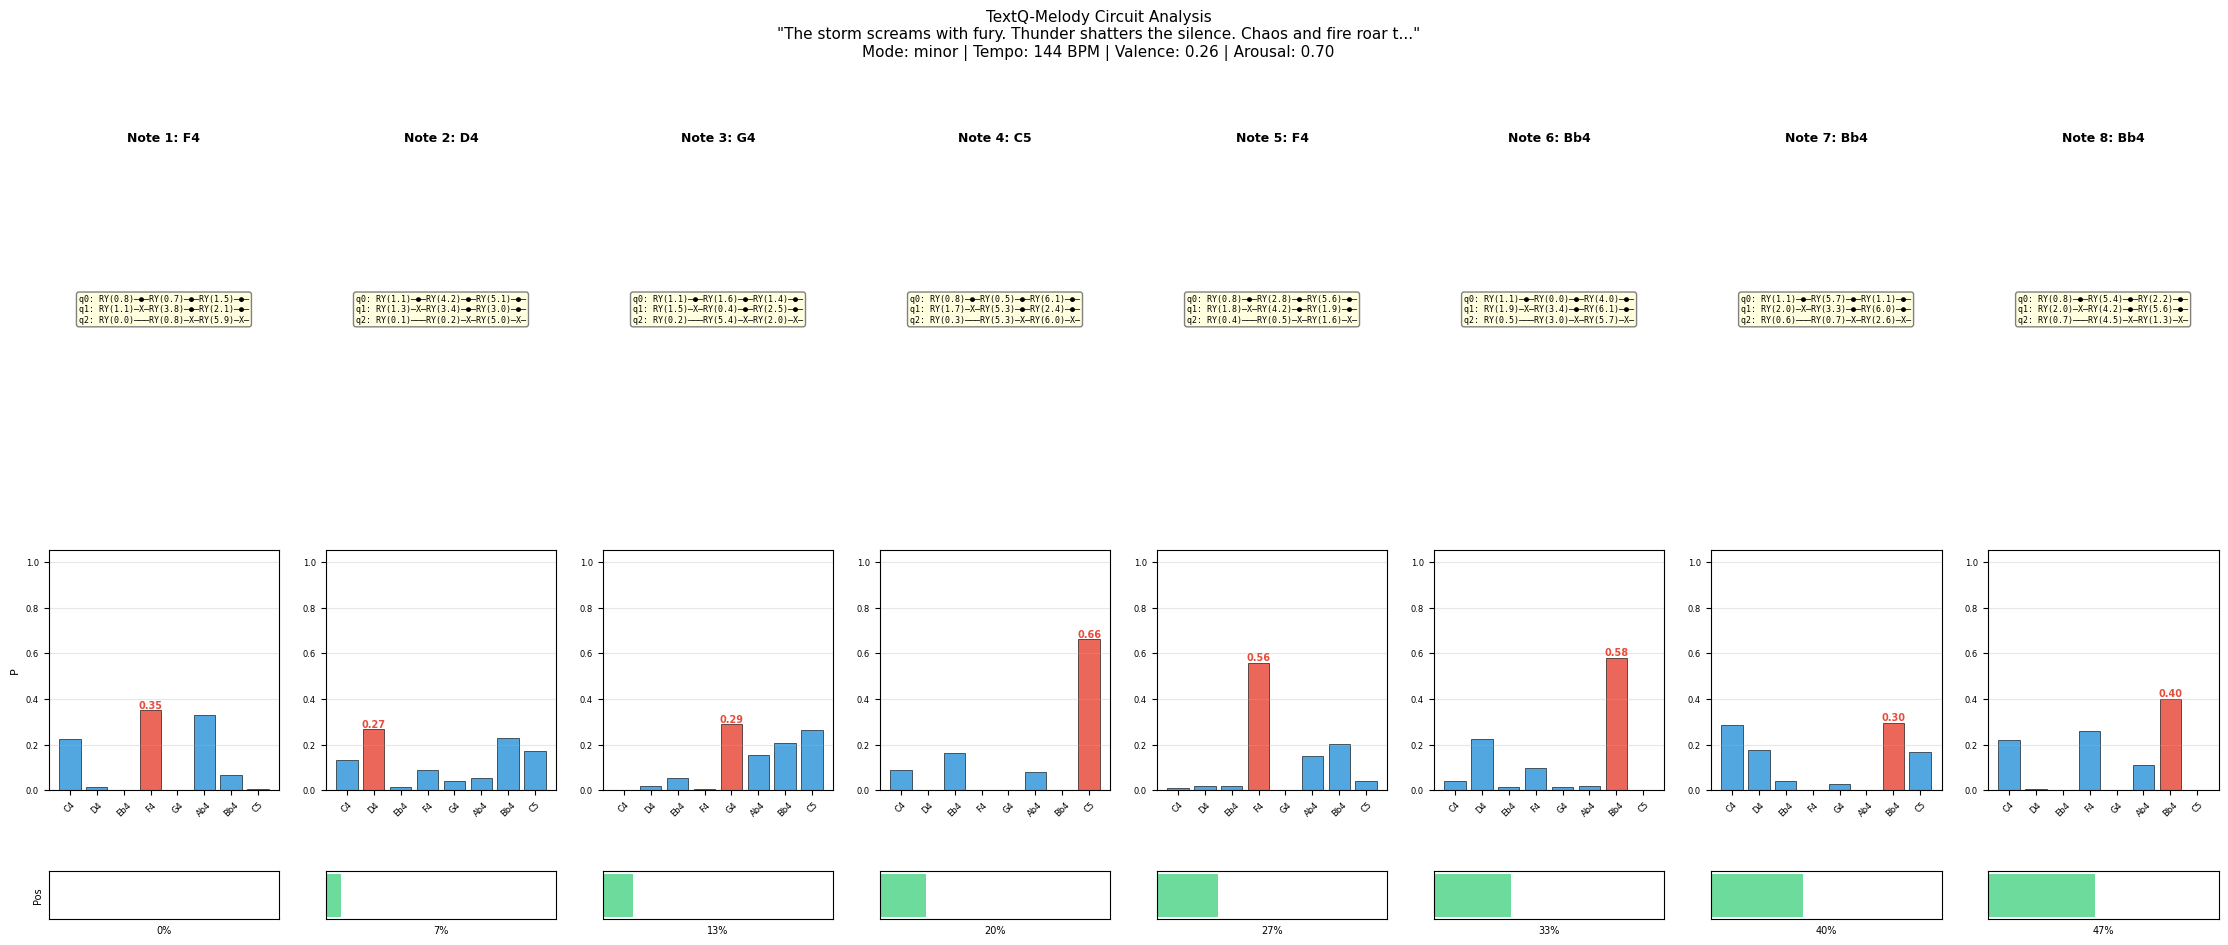

Circuit analysis saved to textq_circuits.png

  SEMANTIC BIAS COMPARISON


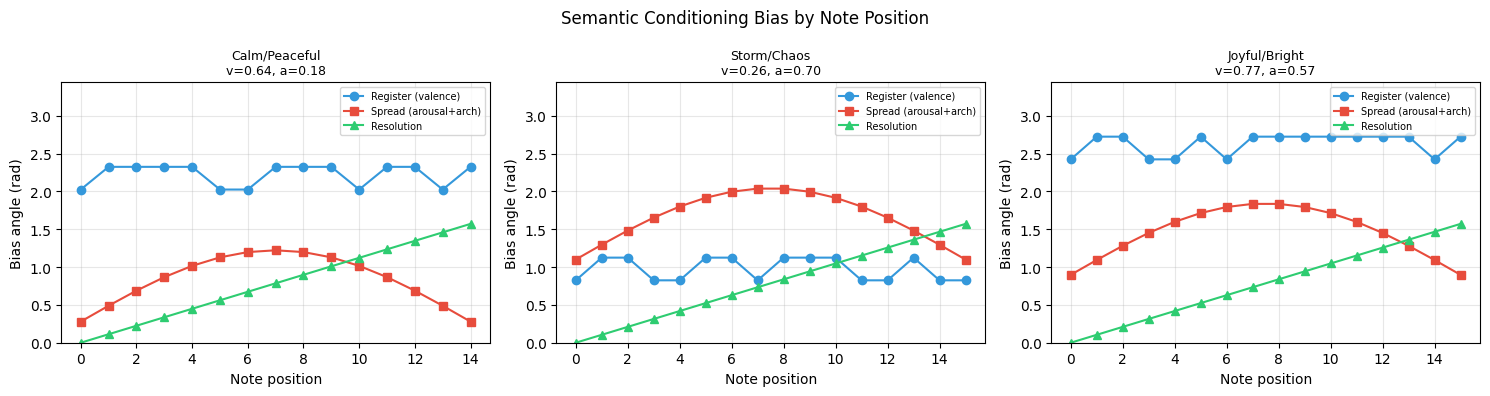

Semantic bias comparison saved to semantic_bias_comparison.png

  MIDI EXPORT

[Composition 1]
  MIDI exported: textq_composition_1.mid
    Instrument: 0 | Tempo: 81 BPM
    Duration:   ~11.1 seconds

[Composition 2]
  MIDI exported: textq_composition_2.mid
    Instrument: 61 | Tempo: 144 BPM
    Duration:   ~6.7 seconds

[Composition 3]
  MIDI exported: textq_composition_3.mid
    Instrument: 48 | Tempo: 128 BPM
    Duration:   ~7.5 seconds

[Combined]
  MIDI exported: textq_combined.mid
    Total duration: ~31.8 seconds


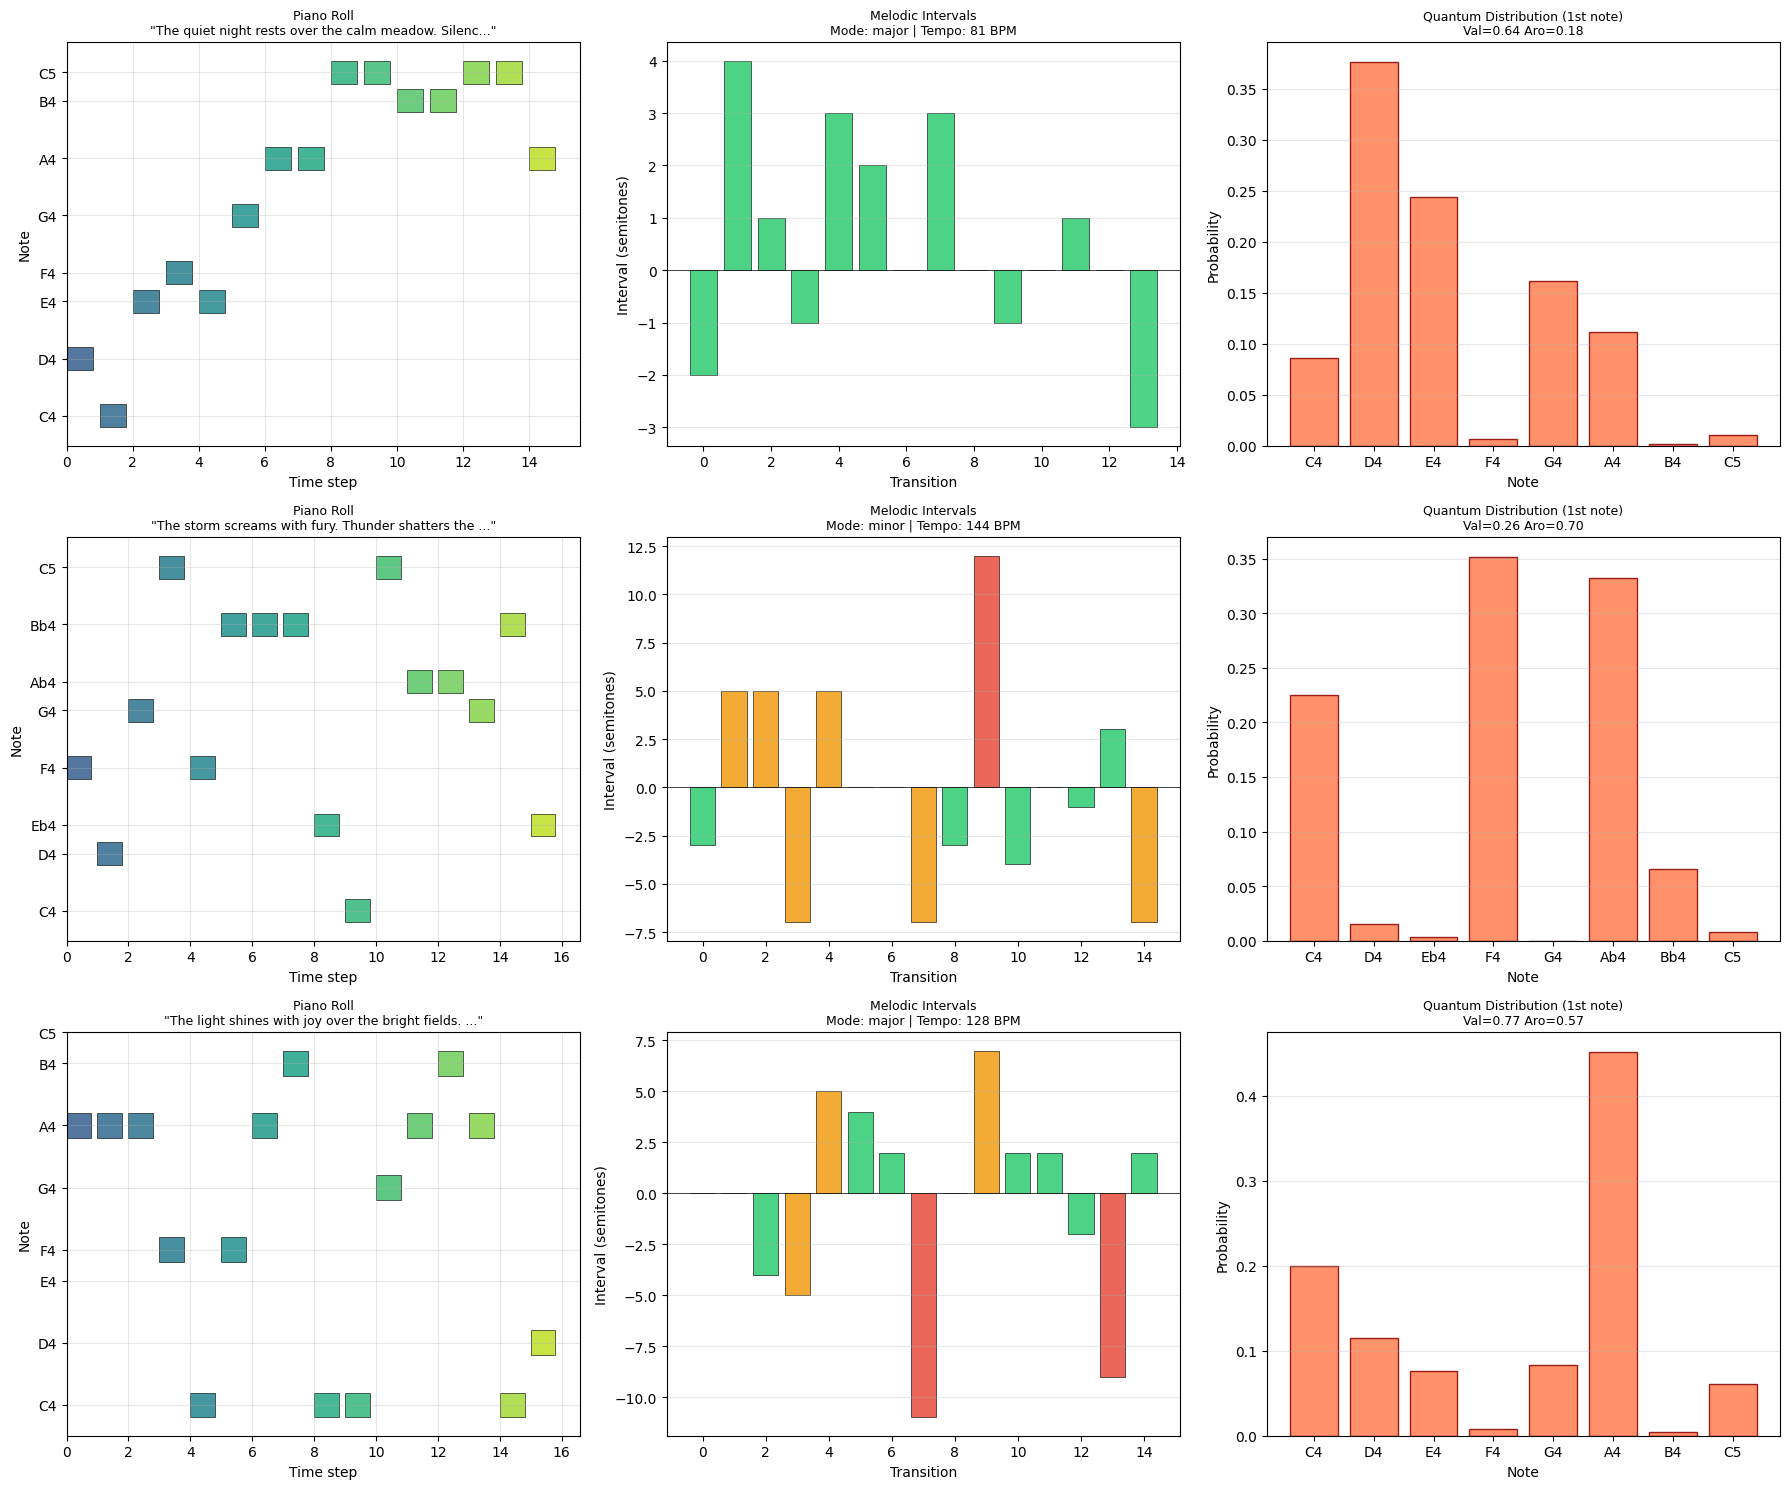


Visualization saved to textq_melody_results.png

Done. Files generated:
  -> textq_composition_1.mid
  -> textq_composition_2.mid
  -> textq_composition_3.mid
  -> textq_combined.mid


In [13]:
# ============================================================
# DEMO: Three contrasting texts
# ============================================================

texts = [
    "The quiet night rests over the calm meadow. "
    "Silence embraces the gentle shadow with peace.",

    "The storm screams with fury. Thunder shatters "
    "the silence. Chaos and fire roar through the dark.",

    "The light shines with joy over the bright fields. "
    "A sweet breeze dances and the flowers sing.",
]

results = []
for i, text in enumerate(texts):
    r = compose_from_text(text, seed=42 + i)
    results.append(r)

# --- Visualization 1: Full Qiskit circuit for one note ---
print("\n" + "=" * 60)
print("  CIRCUIT VISUALIZATION")
print("=" * 60)

# Show circuit for note 1 of the calm text
print("\n[Calm text - Note 1]")
fig1, qc1 = draw_full_qiskit_circuit(results[0], note_index=0)

# Show circuit for note 1 of the storm text (contrast!)
print("\n[Storm text - Note 1]")
fig2, qc2 = draw_full_qiskit_circuit(results[1], note_index=0)

# --- Visualization 2: All notes with probability distributions ---
print("\n[Full melody circuit analysis - Calm text]")
draw_melody_circuits(results[0], max_notes=8)

print("\n[Full melody circuit analysis - Storm text]")
draw_melody_circuits(results[1], max_notes=8)

# --- Visualization 3: Compare semantic bias across texts ---
print("\n" + "=" * 60)
print("  SEMANTIC BIAS COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Calm/Peaceful', 'Storm/Chaos', 'Joyful/Bright']

for idx, (r, label) in enumerate(zip(results, labels)):
    ax = axes[idx]
    sem = r['semantic']
    n_notes = len(r['melody_midi'])

    biases = np.array([semantic_to_bias(sem, i, n_notes) for i in range(n_notes)])

    ax.plot(biases[:, 0], 'o-', label='Register (valence)', color='#3498db')
    ax.plot(biases[:, 1], 's-', label='Spread (arousal+arch)', color='#e74c3c')
    ax.plot(biases[:, 2], '^-', label='Resolution', color='#2ecc71')
    ax.set_xlabel('Note position')
    ax.set_ylabel('Bias angle (rad)')
    ax.set_title(f'{label}\nv={sem["valence"]:.2f}, a={sem["arousal"]:.2f}',
                fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, np.pi + 0.3)

plt.suptitle('Semantic Conditioning Bias by Note Position', fontsize=12)
plt.tight_layout()
plt.savefig('semantic_bias_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Semantic bias comparison saved to semantic_bias_comparison.png")

# Export all MIDI files
midi_files = export_all(results)

# Generate plots
plot_results(results)

print("\nDone. Files generated:")
for f in midi_files:
    print(f"  -> {f}")